In [1]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, f1_score, recall_score, classification_report,
                             confusion_matrix, precision_recall_curve, auc)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Environment and libraries are ready!")

Environment and libraries are ready!


In [ ]:
def combine_files(path):
    print("\n----------------------------------------")
    print("Folder name:", path)
    
    if not os.path.exists(path):
        print(f"❌ Error: Directory does not exist: {path}")
        return []
    
    filenames = [f for f in os.listdir(path) if f.endswith('.csv')]
    print("Number of CSV files:", len(filenames))
    
    dfs = []
    try:
        for filename in filenames:
            file_path = os.path.join(path, filename)
            dfs.append(pd.read_csv(file_path))
        return dfs    
    except Exception as e:
        print("Error reading files:", e)
        return []

try:
    base_path = kagglehub.dataset_download(
        # "ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min"
        "ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45"
    )
    print("Original dataset downloaded at:", base_path)

    cassette_dir = os.path.join(base_path, "cassette")
    telemetry_dir = os.path.join(base_path, "telemetry")
    
    if os.path.exists(os.path.join(cassette_dir, "cassette")):
        cassette_dir = os.path.join(cassette_dir, "cassette")
    if os.path.exists(os.path.join(telemetry_dir, "telemetry")):
        telemetry_dir = os.path.join(telemetry_dir, "telemetry")

    cassette_dfs = combine_files(cassette_dir)
    telemetry_dfs = combine_files(telemetry_dir)
    
    if cassette_dfs or telemetry_dfs:
        print("\n✅ Successfully loaded CSV files from cassette and telemetry!")
        print(f"Total DataFrames from cassette: {len(cassette_dfs)}")
        print(f"Total DataFrames from telemetry: {len(telemetry_dfs)}")
    else:
        print("\n❌ No data loaded. Please check the file structure.")

except Exception as e:
    print("A system error occurred:", e)

Original dataset downloaded at: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min/versions/1

----------------------------------------
Folder name: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min/versions/1/cassette
Number of CSV files: 20

----------------------------------------
Folder name: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/sleep-stage-csv-max-break-time-45-min/versions/1/telemetry
Number of CSV files: 10

✅ Successfully loaded CSV files from cassette and telemetry!
Total DataFrames from cassette: 20
Total DataFrames from telemetry: 10


In [3]:
SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

WINDOW_SIZE = 11  
CENTER_IDX = WINDOW_SIZE // 2  

CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
NUM_CLASSES = len(CLASS_NAMES)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"🚀 Pipeline is running on device: {DEVICE}")

🚀 Pipeline is running on device: cpu


In [4]:
class ANNDataset(Dataset):
    def __init__(self, file_dfs, feature_cols, scaler=None):
        df_all = pd.concat(file_dfs, ignore_index=True)
        self.X_raw = df_all[feature_cols].values
        self.labels = df_all['label'].values.astype(np.int64)
        
        if scaler:
            self.X = scaler.transform(self.X_raw).astype(np.float32)
        else:
            self.X = self.X_raw.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.labels[idx])

In [5]:
class BiLSTMDataset(Dataset):
    def __init__(self, file_dfs, feature_cols, window_size=11, center_idx=5, scaler=None):
        self.windows = []
        self.labels = []
        
        for df in file_dfs:
            if len(df) < window_size:
                continue
            
            X_scaled = scaler.transform(df[feature_cols].values) if scaler else df[feature_cols].values
            y_raw = df['label'].values
            
            for i in range(len(df) - window_size + 1):
                window_data = X_scaled[i : i + window_size]
                center_label = y_raw[i + center_idx]
                
                self.windows.append(window_data)
                self.labels.append(center_label)
                
        self.windows = np.stack(self.windows, axis=0).astype(np.float32) if self.windows else np.empty((0, window_size, len(feature_cols)))
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.windows[idx]), torch.tensor(self.labels[idx])

In [6]:
def robust_per_subject_scaling(dfs, feature_cols):
    processed_dfs = []
    
    for df in dfs:
        df_cp = df.copy()
        X_raw = df_cp[feature_cols].values
        
        if np.isnan(X_raw).sum() > 0 or np.isinf(X_raw).sum() > 0:
            X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=1e5, neginf=-1e5)
        
        q_low = np.percentile(X_raw, 1, axis=0)
        q_high = np.percentile(X_raw, 99, axis=0)
        X_clipped = np.clip(X_raw, q_low, q_high)
        
        scaler_subject = StandardScaler()
        X_scaled = scaler_subject.fit_transform(X_clipped)
        
        df_cp[feature_cols] = X_scaled
        processed_dfs.append(df_cp)
        
    return processed_dfs

def print_distribution(labels, name="Dataset"):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    pcts = counts / len(labels) * 100
    dist_str = ", ".join([f"{CLASS_NAMES[i]}: {counts[i]} ({pcts[i]:.1f}%)" for i in range(NUM_CLASSES)])
    print(f" 📊 {name} Distribution -> Total: {len(labels)} | {dist_str}")

In [7]:
class SimpleANN(nn.Module):
    def __init__(self, input_size, num_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes) # Output Raw Logits
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class CompactBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1, num_classes=5, center_idx=5):
        super().__init__()
        self.center_idx = center_idx
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x) 
        out_center = lstm_out[:, self.center_idx, :]
        
        return self.classifier(out_center)

In [9]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def run_training_loop(model, train_loader, val_loader, class_weights, model_name="Model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    stopper = EarlyStopping(patience=PATIENCE)

    print(f"\n--- 🏋️ Training {model_name} ---")
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x_b.size(0)
        
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        all_logits = []

        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                logits = model(x_b)
                loss = criterion(logits, y_b)
                val_loss += loss.item() * x_b.size(0)

                preds = torch.argmax(logits, dim=-1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(y_b.cpu().numpy())
                all_logits.append(logits.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        macro_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

        unique_predicted_classes = np.unique(val_preds)
        pred_counts = np.bincount(val_preds, minlength=NUM_CLASSES)

        print(f" Epoch {epoch:02d}/{MAX_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {macro_f1:.4f}")
        if len(unique_predicted_classes) == 1:
            print(f"  ⚠️  [CRITICAL WARNING] Logits Collapse Detected! Model predicts only class {unique_predicted_classes[0]} ({CLASS_NAMES[unique_predicted_classes[0]]})")
            print(f"  Distribution: {pred_counts}")

        stopper(val_loss, model)
        if stopper.early_stop:
            print(f" ⏹️ Early stopping activated at epoch {epoch}. Restoring best weights!")
            break

    stopper.restore_best_weights(model)
    return model


def evaluate_final_model(model, test_loader, model_name="Model"):
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b = x_b.to(DEVICE)
            logits = model(x_b)
            probs = F.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)

            all_targets.extend(y_b.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_targets, all_preds)

    y_true_bin = label_binarize(all_targets, classes=list(range(NUM_CLASSES)))
    pr_auc_list = []
    for c in range(NUM_CLASSES):
        p_curve, r_curve, _ = precision_recall_curve(y_true_bin[:, c], all_probs[:, c])
        pr_auc_list.append(auc(r_curve, p_curve))
    macro_pr_auc = np.mean(pr_auc_list)

    metrics = {
        'Accuracy': acc,
        'Precision_Macro': precision,
        'Recall_Macro': recall,
        'F1_Macro': f1,
        'PR_AUC_Macro': macro_pr_auc,
        'Confusion_Matrix': cm,
        'Predictions_Distribution': np.bincount(all_preds, minlength=NUM_CLASSES),
        'True_Targets': all_targets,
        'Pred_Outputs': all_preds
    }

    print(f"\n==================== EVALUATION RESULTS: {model_name.upper()} ====================")
    print(f" • Accuracy:         {acc:.4f}")
    print(f" • Precision Macro:  {precision:.4f}")
    print(f" • Recall Macro:     {recall:.4f}")
    print(f" • F1-Score Macro:   {f1:.4f}")
    print(f" • PR-AUC Macro:     {macro_pr_auc:.4f}")
    print(f" • Predicted class counts: {dict(zip(CLASS_NAMES, metrics['Predictions_Distribution']))}")
    
    return metrics

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
file_majority_labels = [int(df['label'].mode().iloc[0]) for df in cassette_dfs]
train_idx, val_idx = next(skf.split(cassette_dfs, file_majority_labels))

train_files = [cassette_dfs[i] for i in train_idx]
val_files = [cassette_dfs[i] for i in val_idx]
test_files = telemetry_dfs

feature_cols = [col for col in cassette_dfs[0].columns if col != 'label']
print(f"✅ Data split into Train: {len(train_files)} files, Val: {len(val_files)} files, Test: {len(test_files)} files")

print("\n🔄 Applying robust per-subject feature scaling with outlier clipping...")
train_dfs_p = robust_per_subject_scaling(train_files, feature_cols)
val_dfs_p = robust_per_subject_scaling(val_files, feature_cols)
test_dfs_p = robust_per_subject_scaling(test_files, feature_cols)

✅ Data split into Train: 16 files, Val: 4 files, Test: 10 files

🔄 Applying robust per-subject feature scaling with outlier clipping...


In [11]:
print("\n" + "="*70 + "\n🔥 RE-RUN ANN BASELINE\n" + "="*70)

ann_train_set = ANNDataset(train_dfs_p, feature_cols, scaler=None)
ann_val_set = ANNDataset(val_dfs_p, feature_cols, scaler=None)
ann_test_set = ANNDataset(test_dfs_p, feature_cols, scaler=None)

print_distribution(ann_train_set.labels, "ANN Train")
print_distribution(ann_val_set.labels, "ANN Val")
print_distribution(ann_test_set.labels, "ANN Test")

ann_train_loader = DataLoader(ann_train_set, batch_size=BATCH_SIZE, shuffle=True)
ann_val_loader = DataLoader(ann_val_set, batch_size=BATCH_SIZE, shuffle=False)
ann_test_loader = DataLoader(ann_test_set, batch_size=BATCH_SIZE, shuffle=False)

unweighted_loss = torch.ones(NUM_CLASSES, dtype=torch.float32)

ann_model = SimpleANN(input_size=len(feature_cols), num_classes=NUM_CLASSES).to(DEVICE)
ann_model = run_training_loop(ann_model, ann_train_loader, ann_val_loader, unweighted_loss, model_name="Simple ANN")
ann_metrics = evaluate_final_model(ann_model, ann_test_loader, model_name="Simple ANN")


🔥 RE-RUN ANN BASELINE
 📊 ANN Train Distribution -> Total: 14493 | Wake: 614 (4.2%), N1: 1379 (9.5%), N2: 7252 (50.0%), N3: 2239 (15.4%), REM: 3009 (20.8%)
 📊 ANN Val Distribution -> Total: 3664 | Wake: 179 (4.9%), N1: 291 (7.9%), N2: 1675 (45.7%), N3: 835 (22.8%), REM: 684 (18.7%)
 📊 ANN Test Distribution -> Total: 9673 | Wake: 429 (4.4%), N1: 767 (7.9%), N2: 4972 (51.4%), N3: 1466 (15.2%), REM: 2039 (21.1%)

--- 🏋️ Training Simple ANN ---
 Epoch 01/30 | Train Loss: 0.6883 | Val Loss: 0.5357 | Val Macro F1: 0.6838
 Epoch 02/30 | Train Loss: 0.5608 | Val Loss: 0.5088 | Val Macro F1: 0.7206
 Epoch 03/30 | Train Loss: 0.5403 | Val Loss: 0.5198 | Val Macro F1: 0.7098
 Epoch 04/30 | Train Loss: 0.5256 | Val Loss: 0.5112 | Val Macro F1: 0.6926
 Epoch 05/30 | Train Loss: 0.5262 | Val Loss: 0.5150 | Val Macro F1: 0.7010
 Epoch 06/30 | Train Loss: 0.5107 | Val Loss: 0.5246 | Val Macro F1: 0.7015
 Epoch 07/30 | Train Loss: 0.5073 | Val Loss: 0.5339 | Val Macro F1: 0.6906
 ⏹️ Early stopping acti

In [12]:
print("\n" + "="*70 + "\n🔥 RE-RUN COMPACT BiLSTM\n" + "="*70)

bilstm_train_set = BiLSTMDataset(train_dfs_p, feature_cols, window_size=WINDOW_SIZE, center_idx=CENTER_IDX, scaler=None)
bilstm_val_set = BiLSTMDataset(val_dfs_p, feature_cols, window_size=WINDOW_SIZE, center_idx=CENTER_IDX, scaler=None)
bilstm_test_set = BiLSTMDataset(test_dfs_p, feature_cols, window_size=WINDOW_SIZE, center_idx=CENTER_IDX, scaler=None)

print_distribution(bilstm_train_set.labels, "BiLSTM Train (Center Label)")
print_distribution(bilstm_val_set.labels, "BiLSTM Val (Center Label)")
print_distribution(bilstm_test_set.labels, "BiLSTM Test (Center Label)")

bilstm_train_loader = DataLoader(bilstm_train_set, batch_size=BATCH_SIZE, shuffle=True)
bilstm_val_loader = DataLoader(bilstm_val_set, batch_size=BATCH_SIZE, shuffle=False)
bilstm_test_loader = DataLoader(bilstm_test_set, batch_size=BATCH_SIZE, shuffle=False)

lstm_model = CompactBiLSTM(input_size=len(feature_cols), hidden_size=128, num_layers=1, num_classes=NUM_CLASSES, center_idx=CENTER_IDX).to(DEVICE)
lstm_model = run_training_loop(lstm_model, bilstm_train_loader, bilstm_val_loader, unweighted_loss, model_name="BiLSTM")
bilstm_metrics = evaluate_final_model(lstm_model, bilstm_test_loader, model_name="BiLSTM")


🔥 RE-RUN COMPACT BiLSTM
 📊 BiLSTM Train (Center Label) Distribution -> Total: 14333 | Wake: 591 (4.1%), N1: 1284 (9.0%), N2: 7228 (50.4%), N3: 2234 (15.6%), REM: 2996 (20.9%)
 📊 BiLSTM Val (Center Label) Distribution -> Total: 3624 | Wake: 179 (4.9%), N1: 267 (7.4%), N2: 1660 (45.8%), N3: 835 (23.0%), REM: 683 (18.8%)
 📊 BiLSTM Test (Center Label) Distribution -> Total: 9573 | Wake: 408 (4.3%), N1: 719 (7.5%), N2: 4951 (51.7%), N3: 1466 (15.3%), REM: 2029 (21.2%)

--- 🏋️ Training BiLSTM ---
 Epoch 01/30 | Train Loss: 0.5737 | Val Loss: 0.4709 | Val Macro F1: 0.7361
 Epoch 02/30 | Train Loss: 0.4109 | Val Loss: 0.4615 | Val Macro F1: 0.7546
 Epoch 03/30 | Train Loss: 0.3762 | Val Loss: 0.4664 | Val Macro F1: 0.7397
 Epoch 04/30 | Train Loss: 0.3531 | Val Loss: 0.4724 | Val Macro F1: 0.7371
 Epoch 05/30 | Train Loss: 0.3382 | Val Loss: 0.4965 | Val Macro F1: 0.7354
 Epoch 06/30 | Train Loss: 0.3181 | Val Loss: 0.5425 | Val Macro F1: 0.7308
 Epoch 07/30 | Train Loss: 0.3023 | Val Loss: 0


📊 CONCLUSION & COMPARISON REPORT BETWEEN ANN AND BiLSTM
         Metric  Simple ANN Baseline  Compact BiLSTM Model
       Accuracy             0.737310              0.777186
Precision Macro             0.617874              0.681280
   Recall Macro             0.563056              0.606631
 F1-Score Macro             0.570355              0.622524
   PR-AUC Macro             0.621355              0.674649

📝 ANALYSIS CONCLUSION:
 -> RESEARCH HYPOTHESIS SUPPORTED: BiLSTM model improves over ANN Baseline by +5.22% in Macro F1.
    This demonstrates the importance of temporal sequence context information in sleep stage classification.


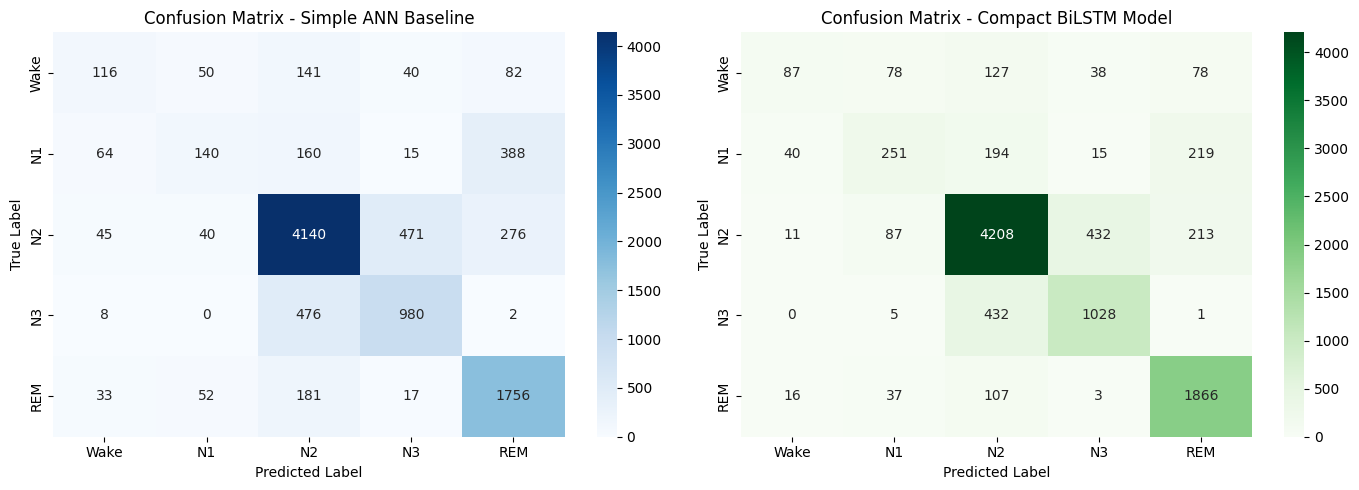

In [13]:
print("\n" + "="*70 + "\n📊 CONCLUSION & COMPARISON REPORT BETWEEN ANN AND BiLSTM\n" + "="*70)

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision Macro','Recall Macro', 'F1-Score Macro', 'PR-AUC Macro'],
    'Simple ANN Baseline': [ann_metrics['Accuracy'], ann_metrics['Precision_Macro'], ann_metrics['Recall_Macro'], ann_metrics['F1_Macro'], ann_metrics['PR_AUC_Macro']],
    'Compact BiLSTM Model': [bilstm_metrics['Accuracy'], bilstm_metrics['Precision_Macro'], bilstm_metrics['Recall_Macro'], bilstm_metrics['F1_Macro'], bilstm_metrics['PR_AUC_Macro']]
})
print(summary_df.to_string(index=False))

f1_diff = bilstm_metrics['F1_Macro'] - ann_metrics['F1_Macro']
print(f"\n📝 ANALYSIS CONCLUSION:")
if f1_diff > 0:
    print(f" -> RESEARCH HYPOTHESIS SUPPORTED: BiLSTM model improves over ANN Baseline by +{f1_diff*100:.2f}% in Macro F1.")
    print("    This demonstrates the importance of temporal sequence context information in sleep stage classification.")
else:
    print(f" -> Experimental results do not show a clear advantage for sequence modeling (BiLSTM change {f1_diff*100:.2f}% vs ANN).")
    print("    Consider checking window_size or temporal feature distribution.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ann_metrics['Confusion_Matrix'], annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix - Simple ANN Baseline")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(bilstm_metrics['Confusion_Matrix'], annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix - Compact BiLSTM Model")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
file_majority_labels = [int(df['label'].mode().iloc[0]) for df in cassette_dfs]

ann_fold_acc, ann_fold_prec, ann_fold_rec, ann_fold_f1 = [], [], [], []
ann_all_folds_data = []
ann_final_gap_targets, ann_final_gap_preds = [], []

bilstm_fold_acc, bilstm_fold_prec, bilstm_fold_rec, bilstm_fold_f1 = [], [], [], []
bilstm_all_folds_data = []
bilstm_final_gap_targets, bilstm_final_gap_preds = [], []

print(f"🔄 Starting 5-Fold Cross-Validation with extended metrics...")

for fold, (train_idx, val_idx) in enumerate(skf.split(cassette_dfs, file_majority_labels), 1):
    print(f"\n" + "#"*80 + f"\n▶️ RUNNING FOLD {fold}/5\n" + "#"*80)
    
    train_files = [cassette_dfs[i] for i in train_idx]
    val_files = [cassette_dfs[i] for i in val_idx]
    test_files = telemetry_dfs
    
    train_dfs_p = robust_per_subject_scaling(train_files, feature_cols)
    val_dfs_p = robust_per_subject_scaling(val_files, feature_cols)
    test_dfs_p = robust_per_subject_scaling(test_files, feature_cols)
    
    ann_train_set = ANNDataset(train_dfs_p, feature_cols, scaler=None)
    ann_val_set = ANNDataset(val_dfs_p, feature_cols, scaler=None)
    ann_test_set = ANNDataset(test_dfs_p, feature_cols, scaler=None)
    
    ann_train_loader = DataLoader(ann_train_set, batch_size=BATCH_SIZE, shuffle=True)
    ann_val_loader = DataLoader(ann_val_set, batch_size=BATCH_SIZE, shuffle=False)
    ann_test_loader = DataLoader(ann_test_set, batch_size=BATCH_SIZE, shuffle=False)
    
    unweighted_loss = torch.ones(NUM_CLASSES, dtype=torch.float32)
    
    ann_model = SimpleANN(input_size=len(feature_cols), num_classes=NUM_CLASSES).to(DEVICE)
    ann_model = run_training_loop(ann_model, ann_train_loader, ann_val_loader, unweighted_loss, model_name=f"ANN Fold {fold}")
    
    ann_model.eval()
    ann_probs, ann_preds, ann_targets = [], [], []
    with torch.no_grad():
        for x_b, y_b in ann_test_loader:
            logits = ann_model(x_b.to(DEVICE))
            probs = F.softmax(logits, dim=-1)
            ann_probs.extend(probs.cpu().numpy())
            ann_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            ann_targets.extend(y_b.numpy())
    ann_probs, ann_targets, ann_preds = np.array(ann_probs), np.array(ann_targets), np.array(ann_preds)
    
    ann_all_folds_data.append((ann_targets, ann_probs))
    ann_final_gap_targets.extend(ann_targets)
    ann_final_gap_preds.extend(ann_preds)
    
    fold_ann_acc = accuracy_score(ann_targets, ann_preds)
    fold_ann_prec = precision_score(ann_targets, ann_preds, average='macro', zero_division=0)
    fold_ann_rec = recall_score(ann_targets, ann_preds, average='macro', zero_division=0)
    fold_ann_f1 = f1_score(ann_targets, ann_preds, average='macro', zero_division=0)
    
    ann_fold_acc.append(fold_ann_acc)
    ann_fold_prec.append(fold_ann_prec)
    ann_fold_rec.append(fold_ann_rec)
    ann_fold_f1.append(fold_ann_f1)
    
    print(f"✨ ANN Fold {fold} results on Telemetry: Acc={fold_ann_acc:.4f} | Prec={fold_ann_prec:.4f} | Rec={fold_ann_rec:.4f} | F1={fold_ann_f1:.4f}")
    
    del ann_model; torch.cuda.empty_cache(); gc.collect()
    
    bilstm_train_set = BiLSTMDataset(train_dfs_p, feature_cols, window_size=WINDOW_SIZE, center_idx=CENTER_IDX, scaler=None)
    bilstm_val_set = BiLSTMDataset(val_dfs_p, feature_cols, window_size=WINDOW_SIZE, center_idx=CENTER_IDX, scaler=None)
    bilstm_test_set = BiLSTMDataset(test_dfs_p, feature_cols, window_size=WINDOW_SIZE, center_idx=CENTER_IDX, scaler=None)
    
    bilstm_train_loader = DataLoader(bilstm_train_set, batch_size=BATCH_SIZE, shuffle=True)
    bilstm_val_loader = DataLoader(bilstm_val_set, batch_size=BATCH_SIZE, shuffle=False)
    bilstm_test_loader = DataLoader(bilstm_test_set, batch_size=BATCH_SIZE, shuffle=False)
    
    lstm_model = CompactBiLSTM(input_size=len(feature_cols), hidden_size=128, num_layers=1, num_classes=NUM_CLASSES, center_idx=CENTER_IDX).to(DEVICE)
    lstm_model = run_training_loop(lstm_model, bilstm_train_loader, bilstm_val_loader, unweighted_loss, model_name=f"BiLSTM Fold {fold}")
    
    lstm_model.eval()
    lstm_probs, lstm_preds, lstm_targets = [], [], []
    with torch.no_grad():
        for x_b, y_b in bilstm_test_loader:
            logits = lstm_model(x_b.to(DEVICE))
            probs = F.softmax(logits, dim=-1)
            lstm_probs.extend(probs.cpu().numpy())
            lstm_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            lstm_targets.extend(y_b.numpy())
    lstm_probs, lstm_targets, lstm_preds = np.array(lstm_probs), np.array(lstm_targets), np.array(lstm_preds)
    
    bilstm_all_folds_data.append((lstm_targets, lstm_probs))
    bilstm_final_gap_targets.extend(lstm_targets)
    bilstm_final_gap_preds.extend(lstm_preds)
    
    fold_lstm_acc = accuracy_score(lstm_targets, lstm_preds)
    fold_lstm_prec = precision_score(lstm_targets, lstm_preds, average='macro', zero_division=0)
    fold_lstm_rec = recall_score(lstm_targets, lstm_preds, average='macro', zero_division=0)
    fold_lstm_f1 = f1_score(lstm_targets, lstm_preds, average='macro', zero_division=0)
    
    bilstm_fold_acc.append(fold_lstm_acc)
    bilstm_fold_prec.append(fold_lstm_prec)
    bilstm_fold_rec.append(fold_lstm_rec)
    bilstm_fold_f1.append(fold_lstm_f1)
    
    print(f"✨ BiLSTM Fold {fold} results on Telemetry: Acc={fold_lstm_acc:.4f} | Prec={fold_lstm_prec:.4f} | Rec={fold_lstm_rec:.4f} | F1={fold_lstm_f1:.4f}")
    
    del lstm_model; torch.cuda.empty_cache(); gc.collect()

🔄 Starting 5-Fold Cross-Validation with extended metrics...

################################################################################
▶️ RUNNING FOLD 1/5
################################################################################

--- 🏋️ Training ANN Fold 1 ---
 Epoch 01/30 | Train Loss: 0.6784 | Val Loss: 0.5314 | Val Macro F1: 0.7011
 Epoch 02/30 | Train Loss: 0.5563 | Val Loss: 0.5431 | Val Macro F1: 0.6853
 Epoch 03/30 | Train Loss: 0.5384 | Val Loss: 0.5151 | Val Macro F1: 0.6983
 Epoch 04/30 | Train Loss: 0.5263 | Val Loss: 0.5270 | Val Macro F1: 0.6716
 Epoch 05/30 | Train Loss: 0.5178 | Val Loss: 0.5356 | Val Macro F1: 0.6819
 Epoch 06/30 | Train Loss: 0.5131 | Val Loss: 0.5201 | Val Macro F1: 0.6993
 Epoch 07/30 | Train Loss: 0.5088 | Val Loss: 0.5130 | Val Macro F1: 0.6907
 Epoch 08/30 | Train Loss: 0.5046 | Val Loss: 0.5293 | Val Macro F1: 0.6945
 Epoch 09/30 | Train Loss: 0.5029 | Val Loss: 0.5057 | Val Macro F1: 0.7088
 Epoch 10/30 | Train Loss: 0.4994 | Val L

In [15]:
print("\n" + "="*70 + "\n📊 AVERAGE CROSS-VALIDATION RESULTS\n" + "="*70)

print(f"Simple ANN Baseline:")
print(f"  • Accuracy:        {np.mean(ann_fold_acc):.4f} ± {np.std(ann_fold_acc):.4f}")
print(f"  • Macro Precision: {np.mean(ann_fold_prec):.4f} ± {np.std(ann_fold_prec):.4f}")
print(f"  • Macro Recall:    {np.mean(ann_fold_rec):.4f} ± {np.std(ann_fold_rec):.4f}")
print(f"  • Macro F1-Score:  {np.mean(ann_fold_f1):.4f} ± {np.std(ann_fold_f1):.4f}")

print(f"\nCompact BiLSTM Model:")
print(f"  • Accuracy:        {np.mean(bilstm_fold_acc):.4f} ± {np.std(bilstm_fold_acc):.4f}")
print(f"  • Macro Precision: {np.mean(bilstm_fold_prec):.4f} ± {np.std(bilstm_fold_prec):.4f}")
print(f"  • Macro Recall:    {np.mean(bilstm_fold_rec):.4f} ± {np.std(bilstm_fold_rec):.4f}")
print(f"  • Macro F1-Score:  {np.mean(bilstm_fold_f1):.4f} ± {np.std(bilstm_fold_f1):.4f}")
print("="*70)


📊 AVERAGE CROSS-VALIDATION RESULTS
Simple ANN Baseline:
  • Accuracy:        0.7342 ± 0.0035
  • Macro Precision: 0.6162 ± 0.0150
  • Macro Recall:    0.5583 ± 0.0085
  • Macro F1-Score:  0.5699 ± 0.0103

Compact BiLSTM Model:
  • Accuracy:        0.7759 ± 0.0018
  • Macro Precision: 0.6868 ± 0.0110
  • Macro Recall:    0.6211 ± 0.0138
  • Macro F1-Score:  0.6369 ± 0.0114


In [16]:
def print_detailed_class_metrics(all_targets, all_preds, class_names):
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    
    print("\n📊 DETAILED PERFORMANCE TABLE BY SLEEP STAGE (TELEMETRY TOTAL):")
    print("-" * 80)
    
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    
    print(f"{'Stage':<12} | {'Precision':<12} | {'Recall':<15} | {'F1-Score':<12} | {'Support'}")
    print("-" * 80)
    
    for label in class_names:
        metrics = report_dict[label]
        print(f"{label:<12} | {metrics['precision']:<12.4f} | {metrics['recall']:<15.4f} | {metrics['f1-score']:<12.4f} | {int(metrics['support']):<12}")
    
    print("-" * 80)
    macro_metrics = report_dict['macro avg']
    print(f"{'Macro Average':<12} | {macro_metrics['precision']:<12.4f} | {macro_metrics['recall']:<15.4f} | {macro_metrics['f1-score']:<12.4f} | {int(macro_metrics['support']):<12}")
    print("-" * 80)

In [17]:
def plot_multiclass_pr_curve_across_folds(all_folds_data, class_names):
    n_classes = len(class_names)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    mean_recall = np.linspace(0, 1, 100)
    
    plt.figure(figsize=(9, 7))
    all_classes_mean_aucs = []
    
    for class_idx in range(n_classes):
        fold_precisions = []
        fold_aucs = []
        
        for y_true, y_probs in all_folds_data:
            y_one_hot = label_binarize(y_true, classes=list(range(n_classes)))
            
            precision, recall, _ = precision_recall_curve(y_one_hot[:, class_idx], y_probs[:, class_idx])
            
            interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
            
            fold_precisions.append(interp_precision)
            fold_aucs.append(auc(recall, precision))
        
        mean_precision = np.mean(fold_precisions, axis=0)
        std_precision = np.std(fold_precisions, axis=0)
        
        mean_auc = np.mean(fold_aucs)
        std_auc = np.std(fold_aucs)
        all_classes_mean_aucs.append(mean_auc)
        
        plt.plot(mean_recall, mean_precision, color=colors[class_idx], lw=2.5,
                 label=f'{class_names[class_idx]} (PR-AUC = {mean_auc:.2f} ± {std_auc:.2f})')
        
        precision_upper = np.minimum(mean_precision + std_precision, 1)
        precision_lower = np.maximum(mean_precision - std_precision, 0)
        plt.fill_between(mean_recall, precision_lower, precision_upper, 
                         color=colors[class_idx], alpha=0.12)
    
    macro_pr_auc = np.mean(all_classes_mean_aucs)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=11)
    plt.ylabel('Precision', fontsize=11)
    plt.title(f'Average Precision-Recall Curve across 5-Folds\n(Telemetry Macro PR-AUC = {macro_pr_auc:.2f})', 
              fontsize=13, fontweight='bold', pad=12)
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


•••••••••••••••••••••••••••••• SIMPLE ANN BASELINE ••••••••••••••••••••••••••••••

📊 DETAILED PERFORMANCE TABLE BY SLEEP STAGE (TELEMETRY TOTAL):
--------------------------------------------------------------------------------
Stage        | Precision    | Recall          | F1-Score     | Support
--------------------------------------------------------------------------------
Wake         | 0.4677       | 0.2056          | 0.2856       | 2145        
N1           | 0.4592       | 0.2626          | 0.3341       | 3835        
N2           | 0.8086       | 0.8350          | 0.8216       | 24860       
N3           | 0.6305       | 0.6518          | 0.6410       | 7330        
REM          | 0.7117       | 0.8363          | 0.7690       | 10195       
--------------------------------------------------------------------------------
Macro Average | 0.6155       | 0.5583          | 0.5703       | 48365       
--------------------------------------------------------------------------------


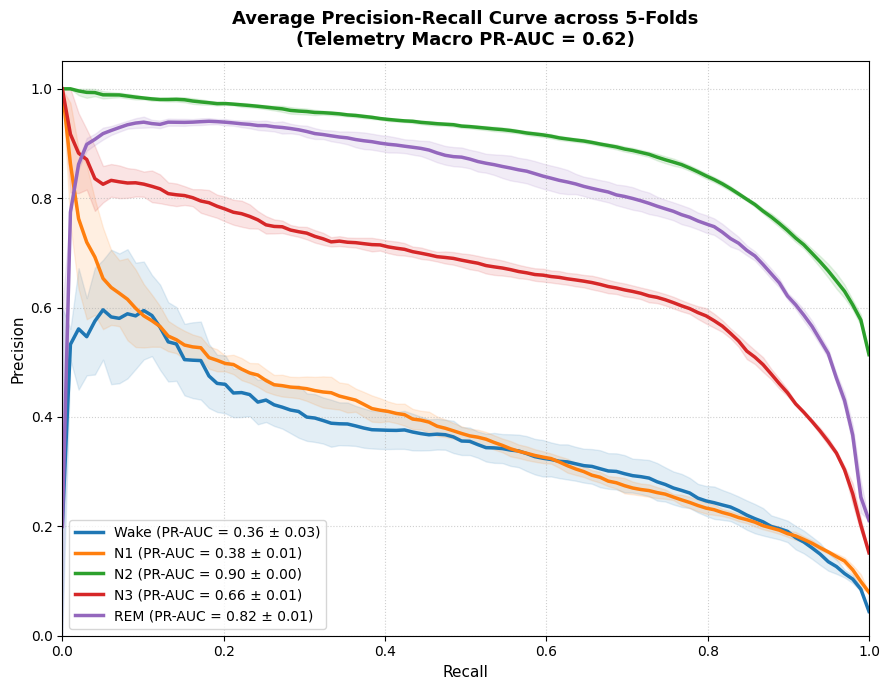


•••••••••••••••••••••••••••••• COMPACT BILSTM ••••••••••••••••••••••••••••••

📊 DETAILED PERFORMANCE TABLE BY SLEEP STAGE (TELEMETRY TOTAL):
--------------------------------------------------------------------------------
Stage        | Precision    | Recall          | F1-Score     | Support
--------------------------------------------------------------------------------
Wake         | 0.6029       | 0.2613          | 0.3646       | 2040        
N1           | 0.4975       | 0.4156          | 0.4529       | 3595        
N2           | 0.8275       | 0.8458          | 0.8365       | 24755       
N3           | 0.6977       | 0.6703          | 0.6837       | 7330        
REM          | 0.7959       | 0.9128          | 0.8503       | 10145       
--------------------------------------------------------------------------------
Macro Average | 0.6843       | 0.6211          | 0.6376       | 47865       
--------------------------------------------------------------------------------


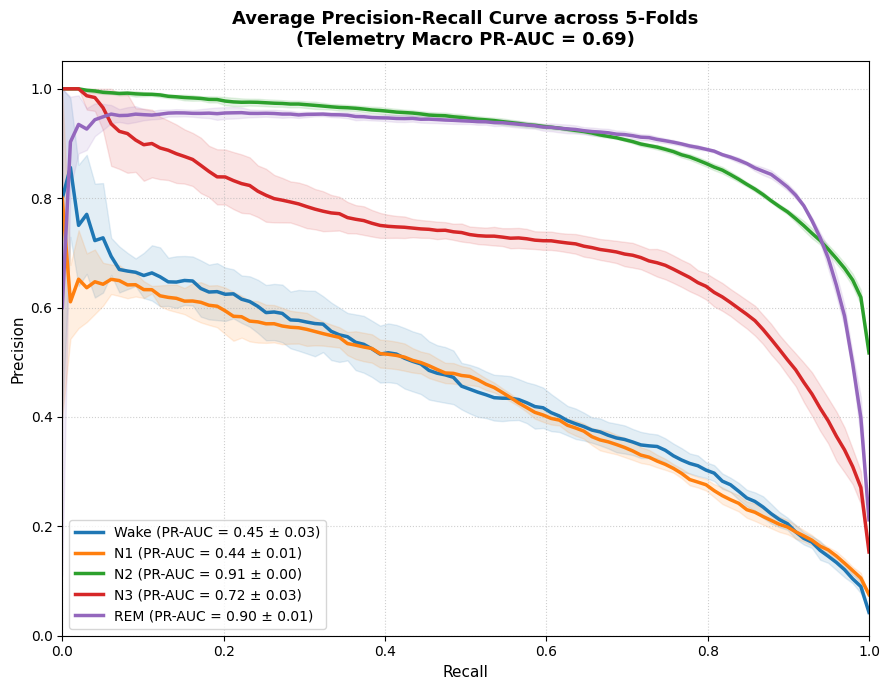

In [18]:
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

print("\n" + "•"*30 + " SIMPLE ANN BASELINE " + "•"*30)
print_detailed_class_metrics(ann_final_gap_targets, ann_final_gap_preds, class_names)
plot_multiclass_pr_curve_across_folds(ann_all_folds_data, class_names)

print("\n" + "•"*30 + " COMPACT BILSTM " + "•"*30)
print_detailed_class_metrics(bilstm_final_gap_targets, bilstm_final_gap_preds, class_names)
plot_multiclass_pr_curve_across_folds(bilstm_all_folds_data, class_names)